# Deep-Dive-Analysis_Task 3

# Import + Load Data

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Video_Games_Sales_Cleaned.csv")
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540americafrontccc.jpg,grand theft auto v,ps3,action,rockstar games,rockstar north,9.40000,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178americafrontccc.jpg,grand theft auto v,ps4,action,rockstar games,rockstar north,9.70000,19.39,6.06,0.60,9.71,3.02,18-11-2014,01-03-2018
2,/games/boxart/827563ccc.jpg,grand theft auto: vice city,ps2,action,rockstar games,rockstar north,9.60000,16.15,8.41,0.47,5.49,1.78,28-10-2002,01-03-2018
3,/games/boxart/full_9218923americafrontccc.jpg,grand theft auto v,x360,action,rockstar games,rockstar north,7.22044,15.86,9.06,0.06,5.33,1.42,17-09-2013,01-03-2018
4,/games/boxart/full_4990510americafrontccc.jpg,call of duty: black ops 3,ps4,shooter,activision,treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,06-11-2015,01-03-2018


# Dataset Info

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     64016 non-null  object 
 6   critic_score  64016 non-null  float64
 7   total_sales   64016 non-null  float64
 8   na_sales      64016 non-null  float64
 9   jp_sales      64016 non-null  float64
 10  pal_sales     64016 non-null  float64
 11  other_sales   64016 non-null  float64
 12  release_date  64016 non-null  object 
 13  last_update   64015 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


# KPI Calculations

In [30]:
total_sales = df['total_sales'].sum()
avg_sales = df['total_sales'].mean()
top_genre = df.groupby('genre')['total_sales'].sum().idxmax()
top_platform = df.groupby('console')['total_sales'].sum().idxmax()
avg_score = df['critic_score'].mean()

print("Total Sales:", total_sales)
print("Average Sales:", avg_sales)
print("Top Genre:", top_genre)
print("Top Platform:", top_platform)
print("Average Critic Score:", avg_score)

Total Sales: 6605.910000000001
Average Sales: 0.10319154586353413
Top Genre: sports
Top Platform: ps2
Average Critic Score: 7.220440251955388


# KPIs into a DataFrame + Plot

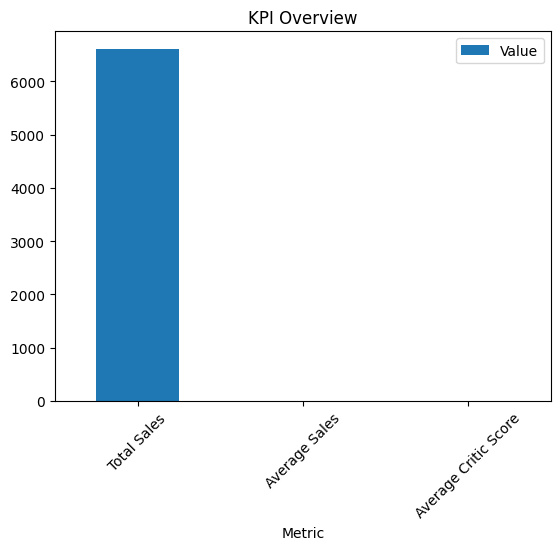

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

kpi_data = pd.DataFrame({
    'Metric': ['Total Sales', 'Average Sales', 'Average Critic Score'],
    'Value': [total_sales, avg_sales, avg_score]
})

kpi_data.plot(x='Metric', y='Value', kind='bar', title="KPI Overview")
plt.xticks(rotation=45)
plt.show()

# Genre Analysis

In [32]:
genre_sales = df.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_sales

genre
sports              1187.51
action              1125.89
shooter              995.50
misc                 557.79
racing               525.75
role-playing         426.80
platform             349.15
fighting             341.13
adventure            325.39
simulation           300.65
action-adventure     148.52
puzzle               127.28
strategy             118.31
music                 51.75
mmo                    9.31
party                  6.21
visual novel           5.78
sandbox                1.89
education              0.97
board game             0.33
Name: total_sales, dtype: float64

# Genre vs Critic Score

In [33]:
genre_score = df.groupby('genre')['critic_score'].mean().sort_values(ascending=False)
genre_score

genre
sandbox             7.319418
music               7.290636
mmo                 7.274137
role-playing        7.258531
education           7.250701
action-adventure    7.247521
fighting            7.244418
strategy            7.241942
platform            7.232710
shooter             7.229556
sports              7.229172
adventure           7.228090
visual novel        7.225631
puzzle              7.218865
racing              7.215510
misc                7.208023
simulation          7.198077
action              7.173474
board game          7.162245
party               7.087811
Name: critic_score, dtype: float64

# KPI Output

In [34]:
print("Total Sales:", total_sales)
print("Average Sales:", avg_sales)
print("Top Genre:", top_genre)
print("Top Platform:", top_platform)

Total Sales: 6605.910000000001
Average Sales: 0.10319154586353413
Top Genre: sports
Top Platform: ps2


# Genre Sales Chart

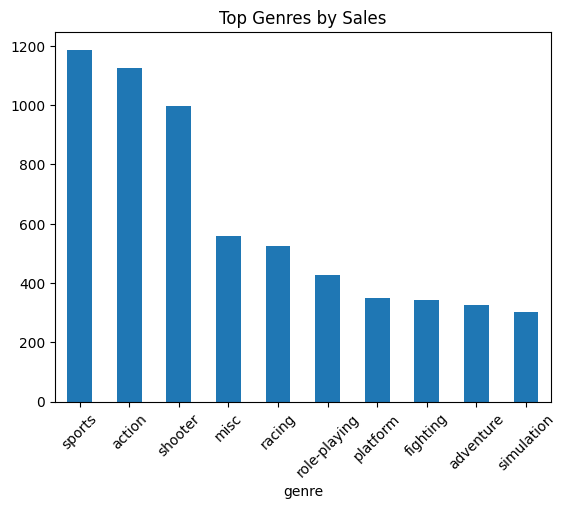

In [35]:
genre_sales.head(10).plot(kind='bar', title="Top Genres by Sales")
plt.xticks(rotation=45)
plt.show()

# Platform Sales Chart

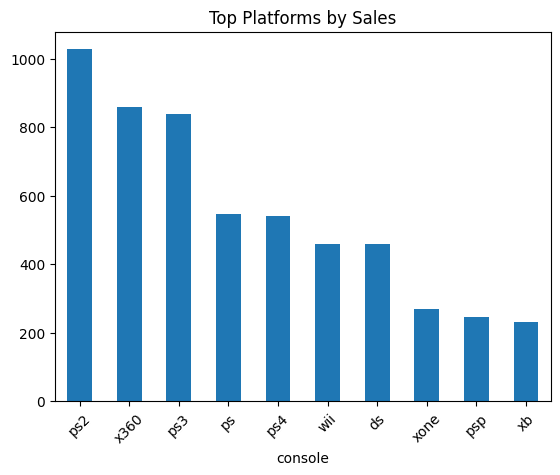

In [36]:
df.groupby('console')['total_sales'].sum().sort_values(ascending=False).head(10).plot(
    kind='bar', title="Top Platforms by Sales"
)
plt.xticks(rotation=45)
plt.show()

# Scatter Plot (Extra Insight)

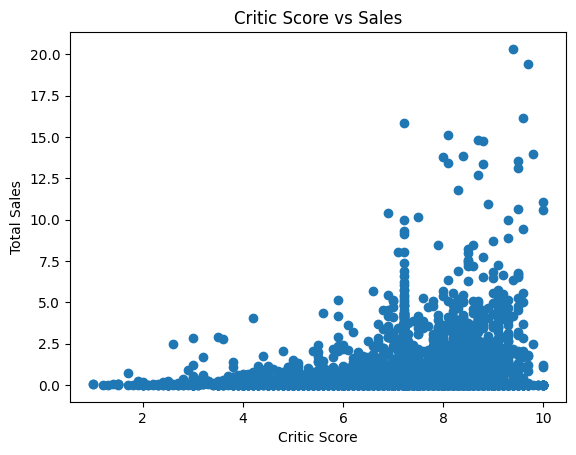

In [37]:
plt.scatter(df['critic_score'], df['total_sales'])
plt.xlabel("Critic Score")
plt.ylabel("Total Sales")
plt.title("Critic Score vs Sales")
plt.show()

# Insights (Markdown)

## Key Insights

- Sports is the top-selling genre
- PS2 is the highest-selling platform
- Most games have low sales
- No strong correlation between critic score and sales
- Sales trend varies over years